### Geographic Distance Notebook for Development Testing

In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from ecd_helperFunctions import *

def mantel_test(matrix1, matrix2, permutations=1000):
    """
    Perform a Mantel test to calculate the correlation between two distance matrices.
    
    Parameters:
        matrix1: numpy array, first distance matrix
        matrix2: numpy array, second distance matrix
        permutations: int, number of permutations for significance testing
    
    Returns:
        mantel_r: Mantel correlation coefficient
        p_value: p-value for the test
    """
    # Flatten the upper triangle of both matrices to get pairwise distances
    dist1 = matrix1[np.triu_indices_from(matrix1, k=1)]
    dist2 = matrix2[np.triu_indices_from(matrix2, k=1)]
    
    # Calculate the Pearson correlation as the Mantel statistic
    mantel_r, _ = pearsonr(dist1, dist2)
    
    # Permutation test for significance
    permuted_rs = []
    for _ in range(permutations):
        permuted = np.random.permutation(dist2)
        permuted_r, _ = pearsonr(dist1, permuted)
        permuted_rs.append(permuted_r)
    
    # Calculate p-value based on permutations
    permuted_rs = np.array(permuted_rs)
    p_value = np.sum(np.abs(permuted_rs) >= np.abs(mantel_r)) / permutations
    
    return mantel_r, p_value

In [3]:
# Simulated example

# Step 1: Simulate protein expression data (e.g., 5 regions, 3 proteins)
np.random.seed(42)
protein_expression = np.random.rand(5, 3)  # 5 regions, 3 proteins

# Step 2: Assign random geographic coordinates (e.g., x, y for 5 regions)
geographic_coordinates = np.random.rand(5, 2)  # 5 regions, 2D space (x, y)

# Step 3: Calculate Molecular Distance Matrix (Euclidean distance between rows of protein_expression)
molecular_distances = pdist(protein_expression, metric='euclidean')
molecular_distance_matrix = squareform(molecular_distances)

# Step 4: Calculate Geographic Distance Matrix (Euclidean distance between rows of geographic_coordinates)
geographic_distances = pdist(geographic_coordinates, metric='euclidean')
geographic_distance_matrix = squareform(geographic_distances)

# Display results
print("Protein Expression (Regions x Proteins):\n", protein_expression)
print("\nGeographic Coordinates (Regions x Coordinates):\n", geographic_coordinates)
print("\nMolecular Distance Matrix:\n", molecular_distance_matrix)
print("\nGeographic Distance Matrix:\n", geographic_distance_matrix)

# Perform Mantel test
mantel_r, p_value = mantel_test(molecular_distance_matrix, geographic_distance_matrix, permutations=1000)

print(f"Mantel Correlation (r): {mantel_r}")
print(f"P-value: {p_value}")

Protein Expression (Regions x Proteins):
 [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497]]

Geographic Coordinates (Regions x Coordinates):
 [[0.18340451 0.30424224]
 [0.52475643 0.43194502]
 [0.29122914 0.61185289]
 [0.13949386 0.29214465]
 [0.36636184 0.45606998]]

Molecular Distance Matrix:
 [[0.         1.00675001 0.35273321 1.01636084 1.02837666]
 [1.00675001 0.         0.99733501 0.83232927 0.24185582]
 [0.35273321 0.99733501 0.         1.12850367 1.09678572]
 [1.01636084 0.83232927 1.12850367 0.         0.82055806]
 [1.02837666 0.24185582 1.09678572 0.82055806 0.        ]]

Geographic Distance Matrix:
 [[0.         0.36445731 0.32596083 0.04554665 0.23774997]
 [0.36445731 0.         0.29479118 0.40984313 0.16022128]
 [0.32596083 0.29479118 0.         0.35388834 0.17295444]
 [0.04554665 0.40984313 0.35388834 0.         0.2798939 ]
 [0.23774997 0.1602

In [8]:
# Divide tissue into ROIs
# Calculate GD for each ROI
# Create a new condensed matrix where each ROI is a single GD value
# Calculate max-sens and infidelity on new condensed matrix

# Load in CSV as dataframe
s1_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S1.csv')


# Create dataframe with only x and y coordinates
s1_xy = s1_df[['x_centroid', 'y_centroid']]

# Create dataframe with intensity values
s1_intensity = s1_df[['sox2_mean', 'cd45_mean']]

# Divide tissue into ROIs
intensity_s1_rois = create_tile_rois(s1_intensity, 
                           tile_size=1000, 
                           x_coord='x_centroid', 
                           y_coord='y_centroid')

# Create dataframe with only x and y coordinates
xy_s1_rois = create_tile_rois(s1_xy, 
                           tile_size=1000, 
                           x_coord='x_centroid', 
                           y_coord='y_centroid')


In [ ]:
# Calculate GD for each ROI
intensity_matrices = intensity_s1_rois.values()
xy_matrices = xy_s1_rois.values()

for intensity_matrix, xy_matrix in zip(intensity_matrices, xy_matrices):
    intensity_perturb = spatial_perturb_matrix(intensity_s1_rois, perturb_columns=['sox2_mean', 'cd45_mean'])
    xy_perturb = spatial_perturb_matrix(xy_s1_rois, perturb_columns=['x_centroid', 'y_centroid'])
    mantel_test(intensity_perturb, xy_perturb, permutations=1000)

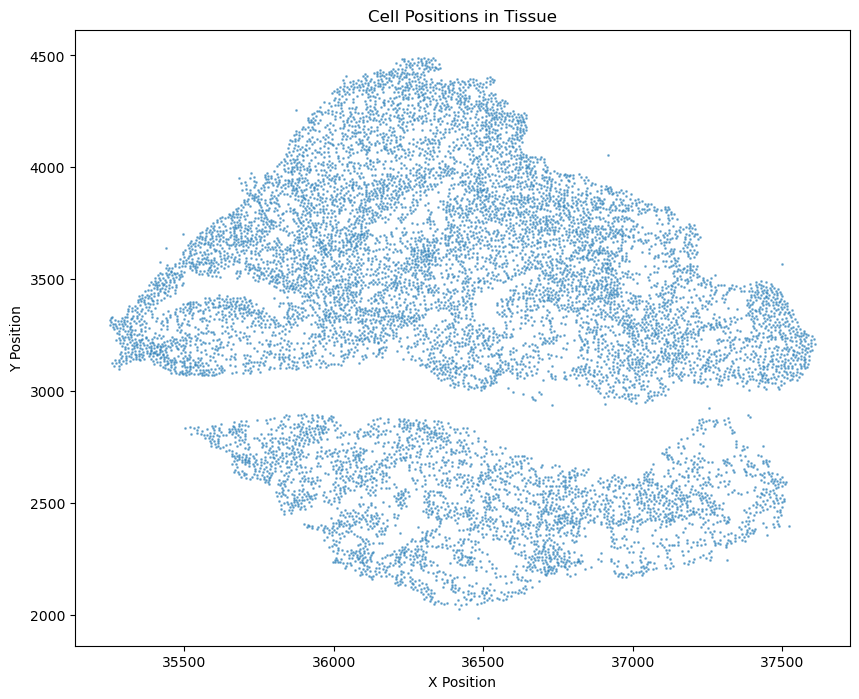

In [9]:
# Create scatter plot of cell positions
plt.figure(figsize=(10, 8))
plt.scatter(s1_df['x_centroid'], s1_df['y_centroid'], alpha=0.5, s=1)
plt.xlabel('X Position')
plt.ylabel('Y Position') 
plt.title('Cell Positions in Tissue')
plt.show()
